# UK Sunburn Cases & UV Index Analysis
Weekly aggregated data visualization showing the relationship between UV index and sunburn/heat-stroke cases in England.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime

# Set style for nice visuals
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# Load the weekly aggregated data
df = pd.read_csv('./data/weekly_aggregated_data.csv')

# Parse the week period string to get start date
df['week_start'] = pd.to_datetime(df['year_week'].str.split('/').str[0])

print(f"Data loaded: {len(df)} weeks")
print(f"Date range: {df['week_start'].min().strftime('%Y-%m-%d')} to {df['week_start'].max().strftime('%Y-%m-%d')}")
df.head()

Data loaded: 64 weeks
Date range: 2024-07-01 to 2025-09-15


,year_week,total_cases,avg_daily_cases,days_count,avg_uv_index,max_uv_index,min_uv_index,week_start
0,2024-07-01/2024-07-07,0.0,0.000000,1,1.340000,1.34,1.34,2024-07-01
1,2024-07-08/2024-07-14,5.0,0.714286,7,0.985714,1.19,0.77,2024-07-08
2,2024-07-15/2024-07-21,35.0,5.000000,7,1.307143,1.73,0.87,2024-07-15
3,2024-07-22/2024-07-28,10.0,1.428571,7,1.312857,1.51,0.93,2024-07-22
4,2024-07-29/2024-08-04,50.0,7.142857,7,1.337143,1.63,0.90,2024-07-29


## 1. Dual-Axis Time Series: UV Index vs Sunburn Cases

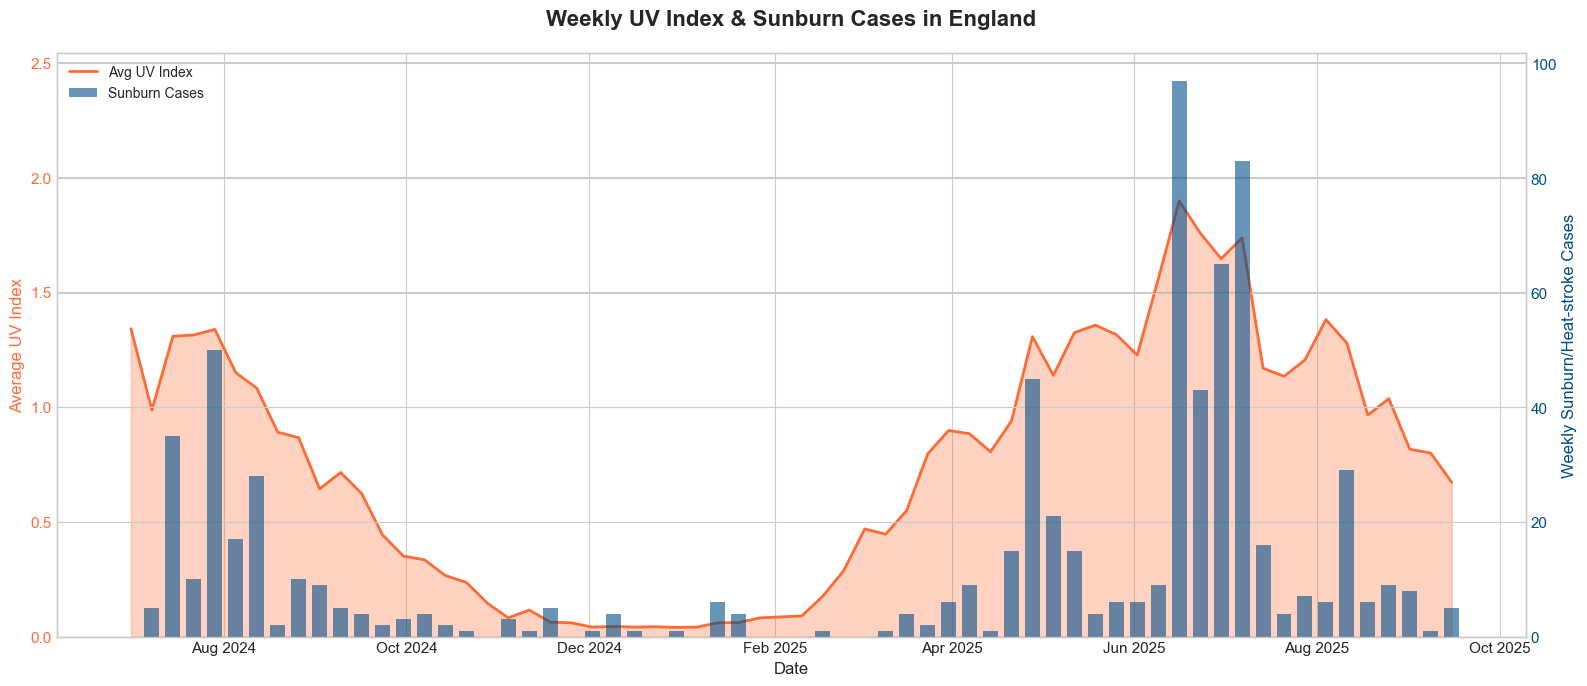

In [3]:
fig, ax1 = plt.subplots(figsize=(16, 7))

# UV Index (left axis)
color_uv = '#FF6B35'
ax1.fill_between(df['week_start'], df['avg_uv_index'], alpha=0.3, color=color_uv)
ax1.plot(df['week_start'], df['avg_uv_index'], color=color_uv, linewidth=2, label='Avg UV Index')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Average UV Index', color=color_uv, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_uv)
ax1.set_ylim(0, df['max_uv_index'].max() * 1.1)

# Sunburn cases (right axis)
ax2 = ax1.twinx()
color_cases = '#004E89'
ax2.bar(df['week_start'], df['total_cases'], alpha=0.6, color=color_cases, width=5, label='Sunburn Cases')
ax2.set_ylabel('Weekly Sunburn/Heat-stroke Cases', color=color_cases, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_cases)

# Formatting
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.title('Weekly UV Index & Sunburn Cases in England', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.savefig('./data/uv_sunburn_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Correlation Scatter Plot

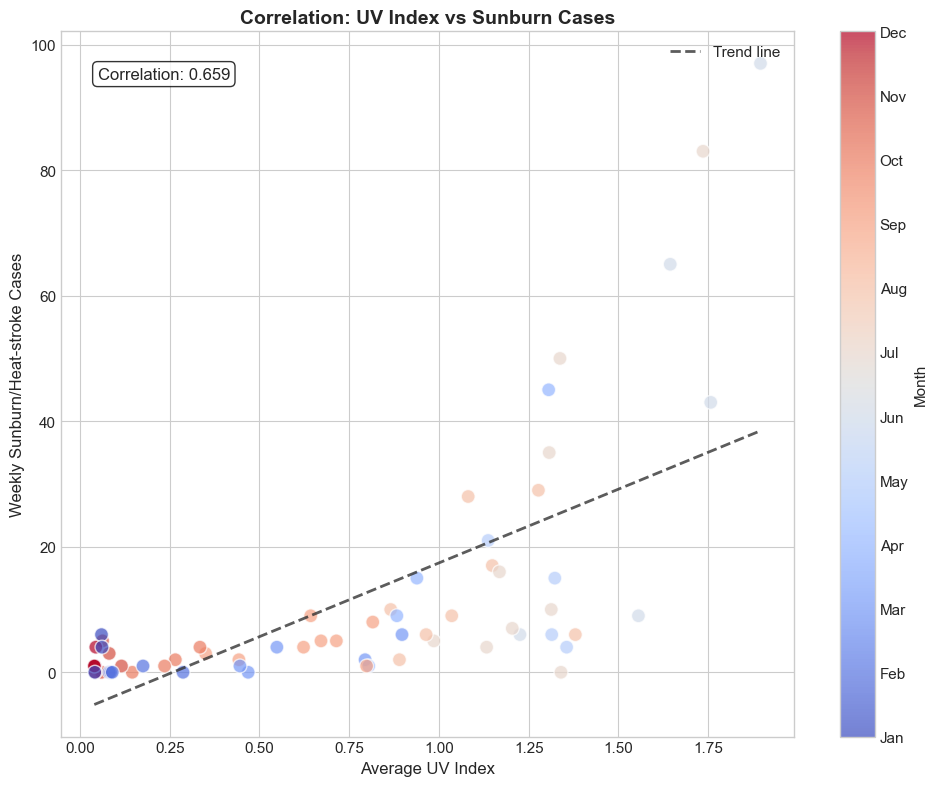

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

# Remove rows with missing values for correlation
df_clean = df.dropna(subset=['avg_uv_index', 'total_cases'])

# Scatter plot with color gradient based on month
scatter = ax.scatter(df_clean['avg_uv_index'], df_clean['total_cases'], 
                     c=df_clean['week_start'].dt.month, cmap='coolwarm', 
                     s=100, alpha=0.7, edgecolors='white', linewidth=1)

# Trend line
z = np.polyfit(df_clean['avg_uv_index'], df_clean['total_cases'], 1)
p = np.poly1d(z)
ax.plot(df_clean['avg_uv_index'].sort_values(), p(df_clean['avg_uv_index'].sort_values()), 
        '--', color='#333', linewidth=2, alpha=0.8, label=f'Trend line')

# Correlation coefficient
corr = df_clean['avg_uv_index'].corr(df_clean['total_cases'])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Average UV Index', fontsize=12)
ax.set_ylabel('Weekly Sunburn/Heat-stroke Cases', fontsize=12)
ax.set_title('Correlation: UV Index vs Sunburn Cases', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter)
cbar.set_label('Month', fontsize=11)
cbar.set_ticks(range(1, 13))
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('./data/uv_sunburn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Monthly Heatmap

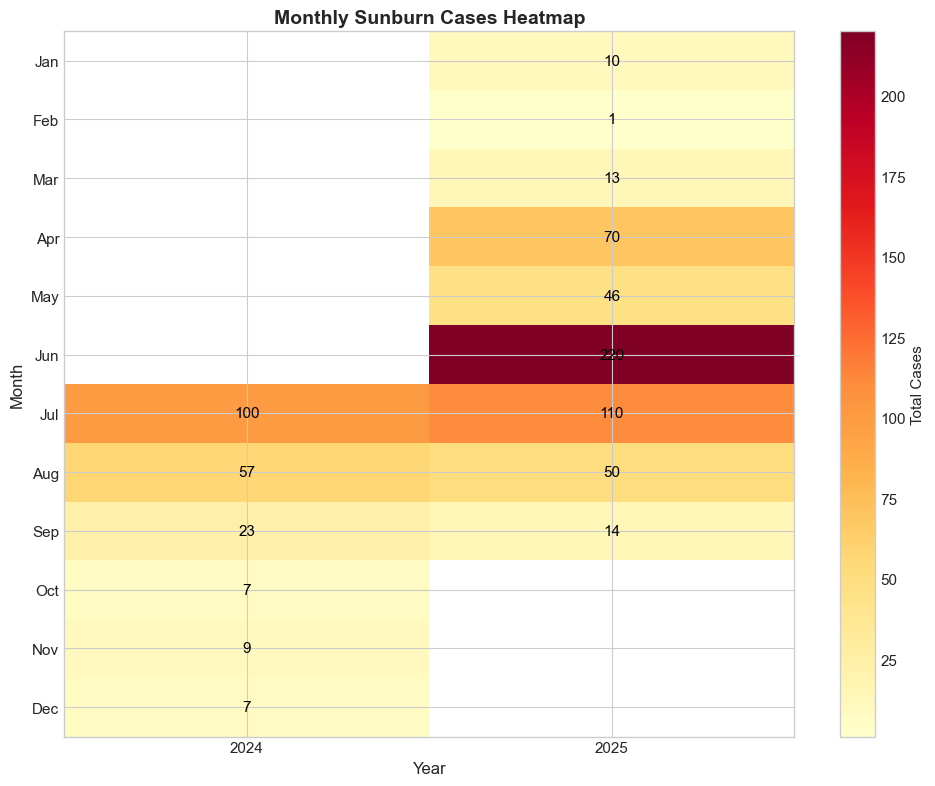

In [5]:
# Create monthly aggregation for heatmap
df['month'] = df['week_start'].dt.month
df['year'] = df['week_start'].dt.year

monthly_pivot = df.pivot_table(values='total_cases', index='month', columns='year', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(monthly_pivot.values, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(range(len(monthly_pivot.columns)))
ax.set_xticklabels(monthly_pivot.columns)
ax.set_yticks(range(len(monthly_pivot.index)))
ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(monthly_pivot.index)])

# Add value annotations
for i in range(len(monthly_pivot.index)):
    for j in range(len(monthly_pivot.columns)):
        val = monthly_pivot.values[i, j]
        if not np.isnan(val):
            text_color = 'white' if val > monthly_pivot.values.max() * 0.5 else 'black'
            ax.text(j, i, f'{int(val)}', ha='center', va='center', color=text_color, fontsize=11)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Month', fontsize=12)
ax.set_title('Monthly Sunburn Cases Heatmap', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im)
cbar.set_label('Total Cases', fontsize=11)

plt.tight_layout()
plt.savefig('./data/sunburn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Summary Statistics

In [6]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"\nTotal sunburn/heat-stroke cases: {df['total_cases'].sum():.0f}")
print(f"Peak weekly cases: {df['total_cases'].max():.0f}")
print(f"Average weekly cases: {df['total_cases'].mean():.1f}")
print(f"\nAverage UV Index: {df['avg_uv_index'].mean():.2f}")
print(f"Max UV Index: {df['max_uv_index'].max():.2f}")
print(f"\nCorrelation (UV Index vs Cases): {df['avg_uv_index'].corr(df['total_cases']):.3f}")
print("=" * 60)

SUMMARY STATISTICS

Total sunburn/heat-stroke cases: 737
Peak weekly cases: 97
Average weekly cases: 11.5

Average UV Index: 0.75
Max UV Index: 2.31

Correlation (UV Index vs Cases): 0.659
